# Reinforcement Learning based Trading Strategy

In this case study, we will create an end-to-end trading strategy based on Reinforcement Learning. 


<a id='1.1'></a>
## 2.1. Loading the python packages

In [1]:
# Load libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas import read_csv, set_option
from pandas.plotting import scatter_matrix
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import datetime
import math
from numpy.random import choice
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from features.ohlcv_tech_indicators import OHLCVWithIndicators


#Import Model Packages for reinforcement learning
from keras import layers, models, optimizers
from keras import backend as K
from collections import namedtuple, deque

<a id='1.2'></a>
## 2.2. Loading the Data

In [ ]:
# Auto-detect all tickers from the data/processed folder
import os
import glob

data_dir = 'data/processed'
train_files = glob.glob(os.path.join(data_dir, '*_train.csv'))

# Extract unique ticker symbols
tickers = sorted(list(set([os.path.basename(f).replace('_train.csv', '') for f in train_files])))
tickers = ['NVDA']
print(f"Found {len(tickers)} tickers: {tickers}")

# Function to load data for a specific ticker
def load_ticker_data(ticker):
    """Load train, val, and test data for a given ticker."""
    train_set = read_csv(f'{data_dir}/{ticker}_train.csv', header=0)
    val_set = read_csv(f'{data_dir}/{ticker}_val.csv', header=0)
    test_set = read_csv(f'{data_dir}/{ticker}_test.csv', header=0)
    return train_set, val_set, test_set

# Display available data
for ticker in tickers:
    train, val, test = load_ticker_data(ticker)
    print(f"{ticker}: Train={train.shape}, Val={val.shape}, Test={test.shape}")

Found 1 tickers: ['CHWY']
CHWY: Train=(1152, 6), Val=(247, 6), Test=(247, 6)


<a id='5.2'></a>
## 5.2. Implementation steps and modules

<a id='5.3'></a>
## 5.3. Agent script

In [3]:
import keras
from keras import layers
from keras.models import Sequential, load_model, clone_model
from keras.layers import Dense
from keras.optimizers import Adam
from collections import deque
import random
import numpy as np


class Agent:
    def __init__(self, state_size, initial_capital=10000, is_eval=False, model_name=""):
        self.state_size = state_size
        self.action_size = 3  # hold, buy, sell

        # Experience Replay Buffer
        self.memory = deque(maxlen=50000)

        self.model_name = model_name
        self.is_eval = is_eval

        # Portfolio tracking
        self.initial_capital = initial_capital
        self.cash = initial_capital
        self.shares_held = 0

        # DQN Hyperparameters
        self.gamma = 0.99            # Discount factor (Rainbow standard)
        self.epsilon = 0.3       # Start fully exploratory
        self.epsilon_min = 0.01      # Keep 1% exploration
        self.epsilon_decay = 0.995   # Per-episode decay

        # Minimum experiences before training starts
        self.train_start = 500

        # Target network update frequency (in training steps)
        self.target_update_freq = 500
        self.train_step_count = 0

        # Build networks
        if is_eval:
            self.model = load_model(model_name)
            self.target_model = clone_model(self.model)
            self.target_model.set_weights(self.model.get_weights())
        else:
            self.model = self._model()
            self.target_model = clone_model(self.model)
            self.target_model.set_weights(self.model.get_weights())

    def reset_portfolio(self):
        """Reset portfolio to initial state for new episode."""
        self.cash = self.initial_capital
        self.shares_held = 0

    def get_portfolio_value(self, current_price):
        """Calculate total portfolio value at current price."""
        return self.cash + (self.shares_held * current_price)

    def _model(self):
        model = Sequential()
        model.add(Dense(units=128, input_dim=self.state_size, activation="relu"))
        model.add(Dense(units=64, activation="relu"))
        model.add(Dense(units=32, activation="relu"))
        model.add(Dense(self.action_size, activation="linear"))
        model.compile(loss="mse", optimizer=Adam(learning_rate=0.0005))
        return model

    def update_target_network(self):
        """Copy online network weights to target network."""
        self.target_model.set_weights(self.model.get_weights())

    def act(self, state):
        """Epsilon-greedy action selection."""
        if not self.is_eval and random.random() <= self.epsilon:
            return random.randrange(self.action_size)
        options = self.model.predict(state, verbose=0)
        return np.argmax(options[0])

    def remember(self, state, action, reward, next_state, done):
        """Store experience in replay buffer."""
        self.memory.append((state, action, reward, next_state, done))

    def expReplay(self, batch_size):
        """
        Experience Replay with Target Network.
        
        Uses the target network for TD target computation (Double DQN idea)
        to stabilize training. The target network is updated every
        target_update_freq training steps.
        """
        if len(self.memory) < self.train_start:
            return

        mini_batch = random.sample(self.memory, min(len(self.memory), batch_size))

        # Vectorize batch
        states = np.vstack([exp[0] for exp in mini_batch])
        actions = np.array([exp[1] for exp in mini_batch])
        rewards = np.array([exp[2] for exp in mini_batch])
        next_states = np.vstack([exp[3] for exp in mini_batch])
        dones = np.array([exp[4] for exp in mini_batch])

        # Online network: current Q-values and action selection for next states
        current_qs = self.model.predict(states, verbose=0)
        next_qs_online = self.model.predict(next_states, verbose=0)

        # Target network: Q-value evaluation for next states
        next_qs_target = self.target_model.predict(next_states, verbose=0)

        # Compute TD targets using Double DQN:
        # action selected by online net, evaluated by target net
        targets = current_qs.copy()
        for i in range(len(mini_batch)):
            if dones[i]:
                targets[i][actions[i]] = rewards[i]
            else:
                best_action = np.argmax(next_qs_online[i])
                targets[i][actions[i]] = rewards[i] + self.gamma * next_qs_target[i][best_action]

        # Single batch training step
        self.model.fit(states, targets, batch_size=batch_size, epochs=1, verbose=0)

        # Update target network periodically
        self.train_step_count += 1
        if self.train_step_count % self.target_update_freq == 0:
            self.update_target_network()

    def decay_epsilon(self):
        """Decay epsilon once per episode (not per replay call)."""
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

<a id='5.4'></a>
## 5.4. Helper Functions

In [4]:
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
from features.ohlcv_tech_indicators import OHLCVWithIndicators


def formatPrice(n):
    """Format a number as a dollar amount."""
    return ("-$" if n < 0 else "$") + "{0:.2f}".format(abs(n))


def sigmoid(x):
    """Sigmoid function (kept for backwards compatibility)."""
    return 1 / (1 + math.exp(-x))


def getState(df, t, window_size, feature_builder, position):
    """
    Build observation using OHLCVWithIndicators.

    Args:
        df: DataFrame with OHLCV + precomputed indicators
        t: Current timestep (must be >= window_size)
        window_size: Size of the lookback window
        feature_builder: OHLCVWithIndicators instance
        position: 1.0 if holding shares, 0.0 if flat

    Returns:
        State vector of shape (1, state_dim) for model input
    """
    return feature_builder.build(df, t, position).reshape(1, -1)


def plot_behavior(data_input, states_buy, states_sell, profit):
    """Plot buy/sell signals on price chart."""
    fig = plt.figure(figsize=(15, 5))
    plt.plot(data_input, color='r', lw=2.)
    plt.plot(data_input, '^', markersize=10, color='m',
             label='Buying signal', markevery=states_buy)
    plt.plot(data_input, 'v', markersize=10, color='k',
             label='Selling signal', markevery=states_sell)
    plt.title('Total gains: %f' % (profit))
    plt.legend()
    plt.show()

<a id='5.5'></a>
## 5.5. Training the data

In [7]:
# =============================================================================
# Configuration
# =============================================================================


window_size = 20
initial_capital = 10000
batch_size = 64
update_frequency = 4
transaction_cost = 0.001  # 0.1% per trade

# Episode design
episode_length = 180    # ~150 trading days per episode
episode_stride = 30       # 30-day stride between episode starts
num_passes = 3            # Number of full passes over the data

# =============================================================================
# Training Function for a Single Ticker
# =============================================================================
def train_ticker(ticker, train_set, window_size, initial_capital, batch_size, 
                 update_frequency, transaction_cost, episode_length, episode_stride, 
                 num_passes, verbose=True):
    """
    Train a DQN agent on a single ticker's data.
    
    Args:
        ticker: Stock ticker symbol (e.g., 'AAPL')
        train_set: Training DataFrame
        window_size: Lookback window for state
        initial_capital: Starting capital
        batch_size: Batch size for experience replay
        update_frequency: Steps between training updates
        transaction_cost: Cost per trade (fraction)
        episode_length: Length of each training episode
        episode_stride: Stride between episode starts
        num_passes: Number of full passes over data
        verbose: Whether to print detailed progress
        
    Returns:
        agent: Trained Agent object
        training_history: Dictionary with training metrics
    """
    # Initialize Feature Builder and Precompute Indicators
    feature_builder = OHLCVWithIndicators(window_size=window_size)
    state_size = feature_builder.obs_dim

    print(f"\n{'#'*70}")
    print(f"# TRAINING: {ticker}")
    print(f"{'#'*70}")
    print(f"State dimension: {state_size}")
    print(f"Transaction cost: {transaction_cost * 100}%")

    # Prepare Training Data
    train_df = train_set.copy()
    train_df = feature_builder.precompute(train_df)
    data = train_df['Close'].tolist()
    l = len(data)

    print(f"Data length: {l} trading days")
    print(f"Training starts from index {window_size}")

    # Generate Episode Start Indices (sliding window with stride)
    episode_starts = []
    start = window_size
    while start + episode_length < l:
        episode_starts.append(start)
        start += episode_stride

    print(f"Episodes per pass: {len(episode_starts)}")
    print(f"Total episodes: {len(episode_starts) * num_passes}")

    # Initialize Agent
    agent = Agent(state_size, initial_capital=initial_capital)
    
    # Training history for plotting
    training_history = {
        'episode_returns': [],
        'episode_values': [],
        'epsilon_history': [],
        'trade_counts': []
    }

    # Training Loop
    global_episode = 0

    for pass_num in range(num_passes):
        # Shuffle episode order each pass for diversity
        shuffled_starts = episode_starts.copy()
        random.shuffle(shuffled_starts)

        for ep_idx, start_idx in enumerate(shuffled_starts):
            global_episode += 1
            end_idx = min(start_idx + episode_length, l - 1)

            if verbose:
                print(f"\n{'='*60}")
                print(f"Pass {pass_num+1}/{num_passes} | Episode {ep_idx+1}/{len(episode_starts)} "
                      f"(Global #{global_episode}) | Epsilon: {agent.epsilon:.3f}")
                print(f"Window: day {start_idx} -> {end_idx} ({end_idx - start_idx} steps)")
                print(f"{'='*60}")

            # Reset portfolio for new episode
            agent.reset_portfolio()
            position = 0.0
            t = start_idx
            state = getState(train_df, t, window_size, feature_builder, position)

            # Track episode stats
            states_buy = []
            states_sell = []
            step_count = 0

            # Store initial portfolio value for terminal bonus
            initial_price = data[t]
            V_initial = agent.get_portfolio_value(initial_price)

            while t < end_idx:
                # Get portfolio value BEFORE action
                V_prev = agent.get_portfolio_value(data[t])

                action = agent.act(state)
                current_price = data[t]

                # EXECUTE ACTION
                if action == 1:  # BUY
                    if agent.cash > 0 and agent.shares_held == 0:
                        trade_value = agent.cash
                        cost = trade_value * transaction_cost
                        net_cash = agent.cash - cost
                        agent.shares_held = net_cash / current_price
                        agent.cash = 0
                        position = 1.0
                        states_buy.append(t)

                elif action == 2:  # SELL
                    if agent.shares_held > 0:
                        gross_sell_value = agent.shares_held * current_price
                        cost = gross_sell_value * transaction_cost
                        agent.cash = gross_sell_value - cost
                        agent.shares_held = 0
                        position = 0.0
                        states_sell.append(t)

                # REWARD
                next_price = data[t + 1] if (t + 1) < l else data[t]
                V_curr = agent.get_portfolio_value(next_price)

                if V_prev > 0 and V_curr > 0:
                    reward = V_curr - V_prev
                else:
                    reward = 0.0

                # TERMINAL BONUS
                done = (t >= end_idx - 1)
                if done:
                    V_final = agent.get_portfolio_value(data[min(t + 1, l - 1)])
                    if V_initial > 0 and V_final > 0:
                        terminal_bonus = V_final - V_initial
                        reward += terminal_bonus

                # Build next state
                next_t = min(t + 1, l - 1)
                next_state = getState(train_df, next_t, window_size, feature_builder, position)

                # Store and learn
                agent.remember(state, action, reward, next_state, done)
                state = next_state
                step_count += 1

                if step_count % update_frequency == 0:
                    agent.expReplay(batch_size)

                t += 1

            # Episode complete — decay epsilon
            agent.decay_epsilon()

            # Record history
            final_value = agent.get_portfolio_value(data[min(end_idx, l - 1)])
            total_return = final_value - initial_capital
            return_pct = (total_return / initial_capital) * 100
            
            training_history['episode_returns'].append(return_pct)
            training_history['episode_values'].append(final_value)
            training_history['epsilon_history'].append(agent.epsilon)
            training_history['trade_counts'].append(len(states_buy) + len(states_sell))

            if verbose:
                print(f"Final Value: {formatPrice(final_value)} | Return: {return_pct:.2f}%")
                print(f"Trades: {len(states_buy)} buys, {len(states_sell)} sells")
                print(f"Memory: {len(agent.memory)} | Train steps: {agent.train_step_count}")

        # Save model at end of each pass with ticker name
        os.makedirs("models", exist_ok=True)
        model_path = f"models/{ticker}_pass{pass_num}.keras"
        agent.model.save(model_path)
        print(f"\nModel saved: {model_path}")

    # Save final model
    final_model_path = f"models/{ticker}_final.keras"
    agent.model.save(final_model_path)
    print(f"\nFinal model saved: {final_model_path}")
    
    print(f"\nTraining complete for {ticker}. Final epsilon: {agent.epsilon:.4f}")
    print(f"Total episodes: {global_episode}")
    print(f"Total training steps: {agent.train_step_count}")
    
    return agent, training_history, feature_builder


def plot_training_history(ticker, history):
    """Plot training metrics for a ticker."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'Training History: {ticker}', fontsize=14, fontweight='bold')
    
    # Episode Returns
    ax1 = axes[0, 0]
    ax1.plot(history['episode_returns'], alpha=0.7)
    ax1.axhline(y=0, color='r', linestyle='--', alpha=0.5)
    # Moving average
    window = min(20, len(history['episode_returns']))
    if window > 1:
        ma = pd.Series(history['episode_returns']).rolling(window=window).mean()
        ax1.plot(ma, color='red', linewidth=2, label=f'{window}-ep MA')
    ax1.set_xlabel('Episode')
    ax1.set_ylabel('Return (%)')
    ax1.set_title('Episode Returns')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Portfolio Values
    ax2 = axes[0, 1]
    ax2.plot(history['episode_values'], alpha=0.7, color='green')
    ax2.axhline(y=initial_capital, color='r', linestyle='--', alpha=0.5, label='Initial Capital')
    ax2.set_xlabel('Episode')
    ax2.set_ylabel('Portfolio Value ($)')
    ax2.set_title('Episode Final Portfolio Values')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Epsilon Decay
    ax3 = axes[1, 0]
    ax3.plot(history['epsilon_history'], color='orange')
    ax3.set_xlabel('Episode')
    ax3.set_ylabel('Epsilon')
    ax3.set_title('Exploration Rate (Epsilon) Decay')
    ax3.grid(True, alpha=0.3)
    
    # Trade Counts
    ax4 = axes[1, 1]
    ax4.plot(history['trade_counts'], alpha=0.7, color='purple')
    if window > 1:
        ma = pd.Series(history['trade_counts']).rolling(window=window).mean()
        ax4.plot(ma, color='red', linewidth=2, label=f'{window}-ep MA')
    ax4.set_xlabel('Episode')
    ax4.set_ylabel('Total Trades')
    ax4.set_title('Trades per Episode')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'models/{ticker}_training_history.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return fig

MULTI-TICKER DQN TRAINING PIPELINE

Tickers to train: ['CHWY']
Configuration:
  - Window size: 20
  - Initial capital: $10000
  - Episode length: 180
  - Number of passes: 3
  - Transaction cost: 0.1%


**********************************************************************
* TICKER 1/1: CHWY
**********************************************************************

######################################################################
# TRAINING: CHWY
######################################################################
State dimension: 107
Transaction cost: 0.1%
Data length: 1152 trading days
Training starts from index 20
Episodes per pass: 32
Total episodes: 96

Pass 1/3 | Episode 1/32 (Global #1) | Epsilon: 0.300
Window: day 830 -> 1010 (180 steps)


/Users/prashanthjaganathan/Desktop/CS5180 - RL/DRLAgents-for-Trading/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Final Value: $7341.02 | Return: -26.59%
Trades: 18 buys, 18 sells
Memory: 180 | Train steps: 0

Pass 1/3 | Episode 2/32 (Global #2) | Epsilon: 0.298
Window: day 200 -> 380 (180 steps)
Final Value: $11700.53 | Return: 17.01%
Trades: 16 buys, 16 sells
Memory: 360 | Train steps: 0

Pass 1/3 | Episode 3/32 (Global #3) | Epsilon: 0.297
Window: day 350 -> 530 (180 steps)
Final Value: $10741.39 | Return: 7.41%
Trades: 13 buys, 13 sells
Memory: 540 | Train steps: 11

Pass 1/3 | Episode 4/32 (Global #4) | Epsilon: 0.296
Window: day 260 -> 440 (180 steps)
Final Value: $22228.45 | Return: 122.28%
Trades: 22 buys, 21 sells
Memory: 720 | Train steps: 56

Pass 1/3 | Episode 5/32 (Global #5) | Epsilon: 0.294
Window: day 710 -> 890 (180 steps)
Final Value: $6906.18 | Return: -30.94%
Trades: 15 buys, 14 sells
Memory: 900 | Train steps: 101

Pass 1/3 | Episode 6/32 (Global #6) | Epsilon: 0.293
Window: day 290 -> 470 (180 steps)
Final Value: $15782.14 | Return: 57.82%
Trades: 14 buys, 13 sells
Memory: 10

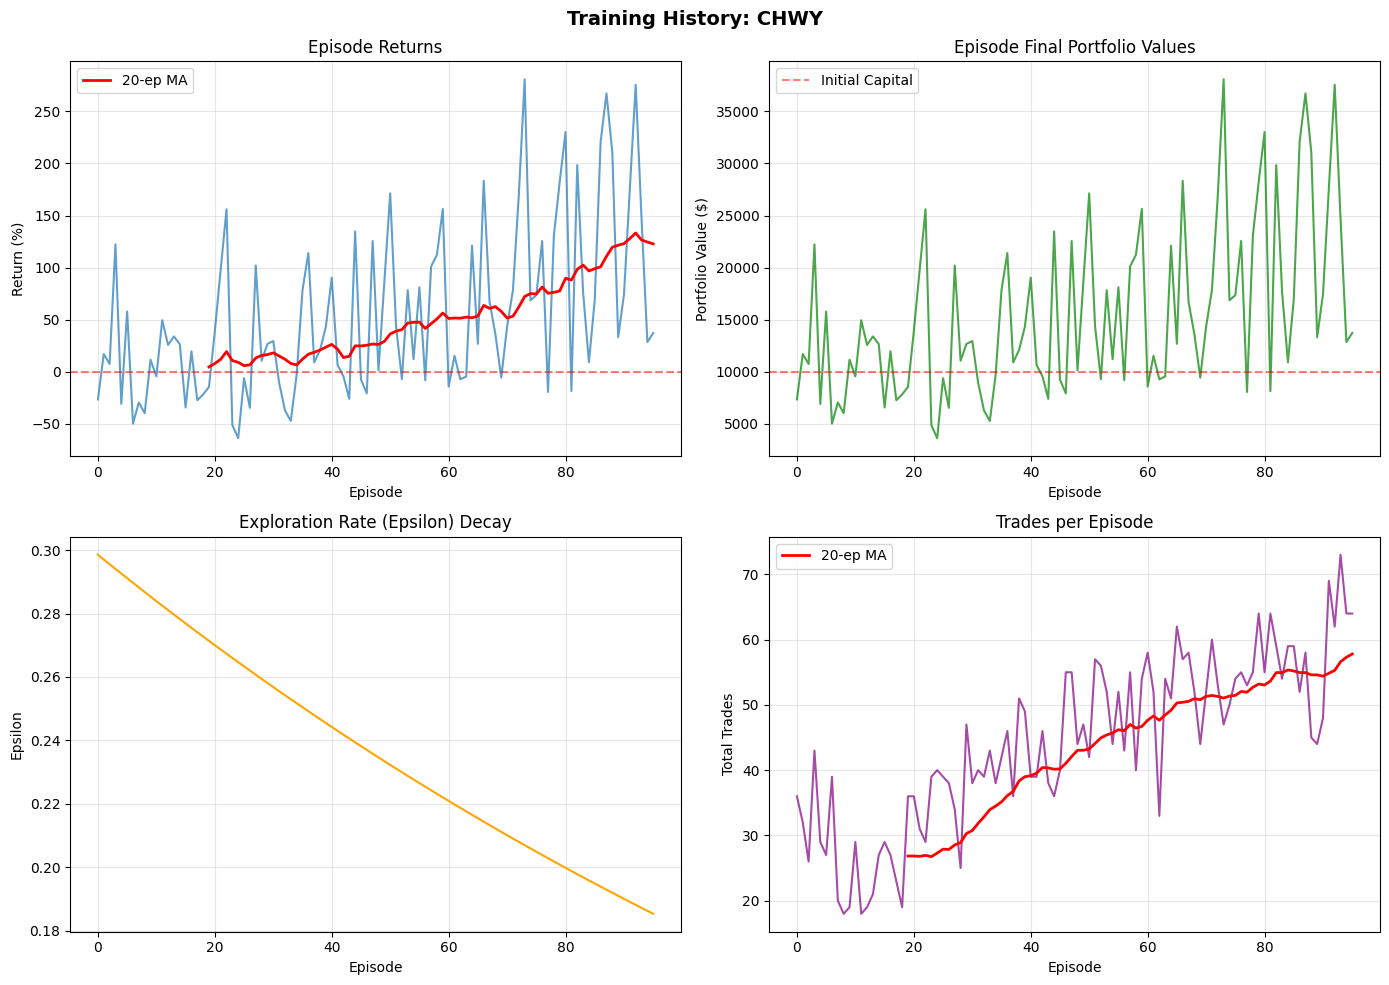


Model Architecture:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │        13,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 72,779 (284.30 KB)

 Trainable params: 24,259 (94.76 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 48,520 (189.54 KB)

None

TRAINING COMPLETE FOR ALL TICKERS

Trained models saved:
  - models/CHWY_final.keras


In [8]:
# =============================================================================
# MAIN TRAINING PIPELINE - TRAIN ALL TICKERS
# =============================================================================
# Dictionary to store trained agents and their results
trained_agents = {}
training_histories = {}
all_results = []

print("=" * 70)
print("MULTI-TICKER DQN TRAINING PIPELINE")
print("=" * 70)
print(f"\nTickers to train: {tickers}")
print(f"Configuration:")
print(f"  - Window size: {window_size}")
print(f"  - Initial capital: ${initial_capital}")
print(f"  - Episode length: {episode_length}")
print(f"  - Number of passes: {num_passes}")
print(f"  - Transaction cost: {transaction_cost*100}%")
print()

for ticker_idx, ticker in enumerate(tickers):
    print(f"\n{'*'*70}")
    print(f"* TICKER {ticker_idx + 1}/{len(tickers)}: {ticker}")
    print(f"{'*'*70}")
    
    # Load data for this ticker
    train_set, val_set, test_set = load_ticker_data(ticker)
    
    # Train the model
    agent, history, feature_builder = train_ticker(
        ticker=ticker,
        train_set=train_set,
        window_size=window_size,
        initial_capital=initial_capital,
        batch_size=batch_size,
        update_frequency=update_frequency,
        transaction_cost=transaction_cost,
        episode_length=episode_length,
        episode_stride=episode_stride,
        num_passes=num_passes,
        verbose=True  # Set to False for less output
    )
    
    # Store agent and history
    trained_agents[ticker] = agent
    training_histories[ticker] = history
    
    # Plot training history
    plot_training_history(ticker, history)
    
    # Print model summary (only for first ticker)
    if ticker_idx == 0:
        print("\nModel Architecture:")
        print(agent.model.summary())

print("\n" + "=" * 70)
print("TRAINING COMPLETE FOR ALL TICKERS")
print("=" * 70)
print("\nTrained models saved:")
for ticker in tickers:
    print(f"  - models/{ticker}_final.keras")

<a id='6'></a>
# 6. Testing the Data 

After training the data, it is tested it against the test dataset. Our model resulted in a overall profit. The best thing about the model was that the profits kept improving over time, indicating that it was learning well and taking better actions.

In [9]:
# =============================================================================
# VALIDATION/TEST EVALUATION FUNCTION
# =============================================================================
def evaluate_ticker(ticker, agent, eval_set, feature_builder, window_size, 
                    initial_capital, transaction_cost, eval_type="VALIDATION"):
    """
    Evaluate a trained agent on validation or test data.
    
    Args:
        ticker: Stock ticker symbol
        agent: Trained Agent object
        eval_set: Evaluation DataFrame (val or test)
        feature_builder: OHLCVWithIndicators instance
        window_size: Lookback window
        initial_capital: Starting capital
        transaction_cost: Cost per trade (fraction)
        eval_type: "VALIDATION" or "TEST"
        
    Returns:
        results: Dictionary with evaluation metrics
    """
    print("=" * 70)
    print(f"{eval_type} SET EVALUATION: {ticker}")
    print("=" * 70)
 
    # Prepare data
    eval_df = eval_set.copy()
    eval_df = feature_builder.precompute(eval_df)
    eval_data = eval_df['Close'].tolist()
    eval_l = len(eval_data) - 1
 
    # Set agent to evaluation mode
    agent.is_eval = True
    agent.epsilon = 0.0
 
    # Reset portfolio
    agent.reset_portfolio()
 
    # Initialize tracking
    t = window_size
    position = 0.0
    state = getState(eval_df, t, window_size, feature_builder, position)
 
    states_buy = []
    states_sell = []
    trades = []
    total_transaction_costs = 0.0
    buy_entry_cost = 0.0
 
    print(f"\nStarting Capital: {formatPrice(initial_capital)}")
    print(f"{eval_type} Period: {eval_l - window_size} trading days")
    print("-" * 70)
    print(f"{'Action':<8} {'Time':<8} {'Price':<12} {'Shares':<12} {'Trade P/L':<12} {'TxnCost':<10} {'Portfolio':<12}")
    print("-" * 70)
 
    while t < eval_l:
        action = agent.act(state)
        current_price = eval_data[t]
        trade_info = None
 
        if action == 1:  # BUY
            if agent.cash > 0 and agent.shares_held == 0:
                trade_value = agent.cash
                cost = trade_value * transaction_cost
                net_cash = agent.cash - cost
                buy_entry_cost = agent.cash
                agent.shares_held = net_cash / current_price
                agent.cash = 0
                position = 1.0
                total_transaction_costs += cost
                states_buy.append(t)
 
                portfolio_value = agent.get_portfolio_value(current_price)
                trade_info = {
                    'action': 'BUY', 'time': t, 'price': current_price,
                    'shares': agent.shares_held, 'trade_pnl': -cost,
                    'txn_cost': cost, 'portfolio': portfolio_value
                }
                print(f"{'BUY':<8} {t:<8} {formatPrice(current_price):<12} "
                      f"{agent.shares_held:<12.4f} {formatPrice(-cost):<12} "
                      f"{formatPrice(cost):<10} {formatPrice(portfolio_value):<12}")
 
        elif action == 2:  # SELL
            if agent.shares_held > 0:
                gross_sell_value = agent.shares_held * current_price
                cost = gross_sell_value * transaction_cost
                net_sell_value = gross_sell_value - cost
                trade_pnl = net_sell_value - buy_entry_cost
                shares_sold = agent.shares_held
                agent.cash = net_sell_value
                agent.shares_held = 0
                position = 0.0
                total_transaction_costs += cost
                states_sell.append(t)
 
                portfolio_value = agent.get_portfolio_value(current_price)
                trade_info = {
                    'action': 'SELL', 'time': t, 'price': current_price,
                    'shares': shares_sold, 'trade_pnl': trade_pnl,
                    'txn_cost': cost, 'portfolio': portfolio_value
                }
                print(f"{'SELL':<8} {t:<8} {formatPrice(current_price):<12} "
                      f"{shares_sold:<12.4f} {formatPrice(trade_pnl):<12} "
                      f"{formatPrice(cost):<10} {formatPrice(portfolio_value):<12}")
 
        if trade_info:
            trades.append(trade_info)
 
        done = (t == eval_l - 1)
        next_state = getState(eval_df, t + 1, window_size, feature_builder, position) if not done else state
        state = next_state
        t += 1
 
    # LIQUIDATE if still holding
    final_price = eval_data[eval_l - 1]
    if agent.shares_held > 0:
        gross_sell_value = agent.shares_held * final_price
        liquidation_cost = gross_sell_value * transaction_cost
        net_liquidation = gross_sell_value - liquidation_cost
        trade_pnl = net_liquidation - buy_entry_cost
        total_transaction_costs += liquidation_cost
 
        print(f"\n--- LIQUIDATION at end of period ---")
        print(f"{'SELL':<8} {'END':<8} {formatPrice(final_price):<12} "
              f"{agent.shares_held:<12.4f} {formatPrice(trade_pnl):<12} "
              f"{formatPrice(liquidation_cost):<10} {formatPrice(net_liquidation):<12}")
 
        trades.append({
            'action': 'SELL', 'time': eval_l, 'price': final_price,
            'shares': agent.shares_held, 'trade_pnl': trade_pnl,
            'txn_cost': liquidation_cost, 'portfolio': net_liquidation
        })
        states_sell.append(eval_l)
        agent.cash = net_liquidation
        agent.shares_held = 0
 
    # Calculate results
    final_portfolio = agent.cash
    dqn_return = final_portfolio - initial_capital
    dqn_return_pct = (dqn_return / initial_capital) * 100
 
    # Buy and Hold Comparison
    start_price = eval_data[window_size]
    end_price = eval_data[eval_l - 1]
    bh_buy_cost = initial_capital * transaction_cost
    bh_shares = (initial_capital - bh_buy_cost) / start_price
    bh_gross_sell = bh_shares * end_price
    bh_sell_cost = bh_gross_sell * transaction_cost
    bh_final_value = bh_gross_sell - bh_sell_cost
    bh_return = bh_final_value - initial_capital
    bh_return_pct = (bh_return / initial_capital) * 100
    bh_total_costs = bh_buy_cost + bh_sell_cost
 
    # Trade Analysis
    sell_trades = [t for t in trades if t['action'] == 'SELL']
    winning_trades = [t for t in sell_trades if t['trade_pnl'] > 0]
    losing_trades = [t for t in sell_trades if t['trade_pnl'] <= 0]
    total_wins = sum(t['trade_pnl'] for t in winning_trades)
    total_losses = sum(t['trade_pnl'] for t in losing_trades)
 
    # Print Summary
    print("\n" + "=" * 70)
    print(f"{eval_type} SET RESULTS SUMMARY: {ticker}")
    print("=" * 70)
    print(f"\n{'DQN STRATEGY':^35} | {'BUY & HOLD':^35}")
    print("-" * 70)
    print(f"{'Initial Capital:':<20} {formatPrice(initial_capital):<15} | {'Initial Capital:':<20} {formatPrice(initial_capital):<15}")
    print(f"{'Final Portfolio:':<20} {formatPrice(final_portfolio):<15} | {'Final Value:':<20} {formatPrice(bh_final_value):<15}")
    print(f"{'Total Return:':<20} {formatPrice(dqn_return):<15} | {'Total Return:':<20} {formatPrice(bh_return):<15}")
    print(f"{'Return %:':<20} {dqn_return_pct:<14.2f}% | {'Return %:':<20} {bh_return_pct:<14.2f}%")
    print(f"\n{'Total Txn Costs:':<20} {formatPrice(total_transaction_costs):<15} | {'Total Txn Costs:':<20} {formatPrice(bh_total_costs):<15}")
    print(f"{'Total Trades:':<20} {len(trades):<15} | {'Total Trades:':<20} {'2':<15}")
    print(f"{'  - Buys:':<20} {len(states_buy):<15}")
    print(f"{'  - Sells:':<20} {len(states_sell):<15}")
 
    if len(sell_trades) > 0:
        print(f"\n{'TRADE STATISTICS':^70}")
        print("-" * 70)
        print(f"{'Winning Trades:':<25} {len(winning_trades)}")
        print(f"{'Losing Trades:':<25} {len(losing_trades)}")
        win_rate = len(winning_trades) / len(sell_trades) * 100
        print(f"{'Win Rate:':<25} {win_rate:.1f}%")
        print(f"{'Total Profit (wins):':<25} {formatPrice(total_wins)}")
        print(f"{'Total Loss (losses):':<25} {formatPrice(total_losses)}")
        if len(winning_trades) > 0:
            print(f"{'Avg Win:':<25} {formatPrice(total_wins / len(winning_trades))}")
        if len(losing_trades) > 0:
            print(f"{'Avg Loss:':<25} {formatPrice(total_losses / len(losing_trades))}")
 
    print(f"\n{'COST ANALYSIS':^70}")
    print("-" * 70)
    print(f"{'Total Txn Costs:':<25} {formatPrice(total_transaction_costs)}")
    print(f"{'Net Return:':<25} {formatPrice(dqn_return)}")
    print(f"{'Costs as % of Capital:':<25} {(total_transaction_costs/initial_capital)*100:.2f}%")
 
    print("\n" + "-" * 70)
    if dqn_return > bh_return:
        outperformance = dqn_return - bh_return
        print(f"DQN OUTPERFORMED Buy & Hold by {formatPrice(outperformance)} ({(outperformance/initial_capital)*100:.2f}%)")
    else:
        underperformance = bh_return - dqn_return
        print(f"DQN UNDERPERFORMED Buy & Hold by {formatPrice(underperformance)} ({(underperformance/initial_capital)*100:.2f}%)")
    print("=" * 70)
    
    # Plot
    plot_behavior(eval_data, states_buy, states_sell, dqn_return)
    
    # Return results dictionary
    results = {
        'ticker': ticker,
        'eval_type': eval_type,
        'final_portfolio': final_portfolio,
        'dqn_return': dqn_return,
        'dqn_return_pct': dqn_return_pct,
        'bh_return': bh_return,
        'bh_return_pct': bh_return_pct,
        'total_trades': len(trades),
        'num_buys': len(states_buy),
        'num_sells': len(states_sell),
        'total_transaction_costs': total_transaction_costs,
        'outperformance': dqn_return - bh_return,
        'win_rate': len(winning_trades) / len(sell_trades) * 100 if len(sell_trades) > 0 else 0
    }
    
    return results

EVALUATION PIPELINE - ALL TICKERS

**********************************************************************
* EVALUATING: CHWY
**********************************************************************
VALIDATION SET EVALUATION: CHWY

Starting Capital: $10000.00
VALIDATION Period: 226 trading days
----------------------------------------------------------------------
Action   Time     Price        Shares       Trade P/L    TxnCost    Portfolio   
----------------------------------------------------------------------
BUY      25       $16.80       594.6429     -$10.00      $10.00     $9990.00    
SELL     26       $16.50       594.6429     -$198.20     $9.81      $9801.80    
BUY      27       $16.04       610.4734     -$9.80       $9.80      $9791.99    
SELL     33       $17.64       610.4734     $956.19      $10.77     $10757.98   
BUY      39       $17.70       607.1878     -$10.76      $10.76     $10747.22   
SELL     41       $17.98       607.1878     $148.34      $10.92     $10906.32  

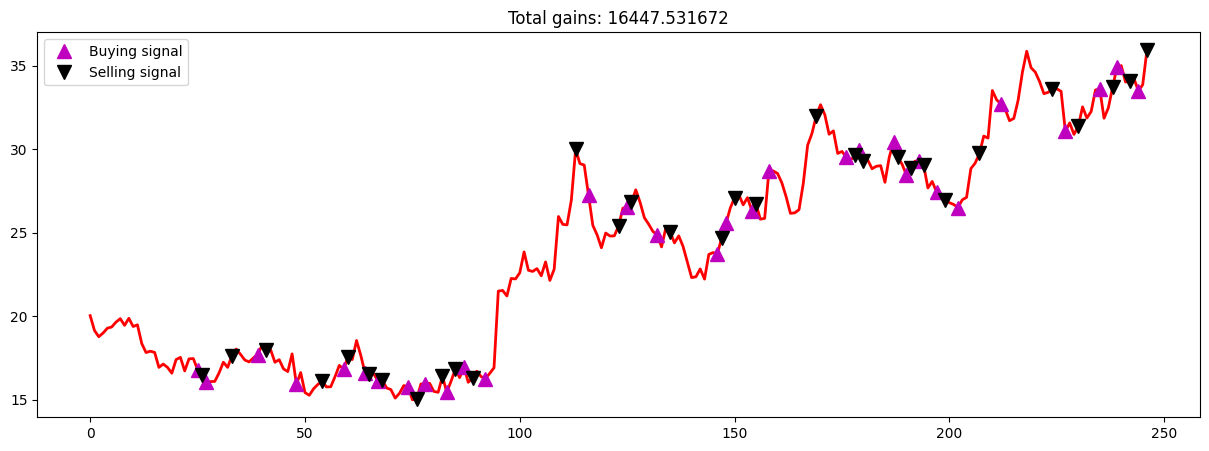

TEST SET EVALUATION: CHWY

Starting Capital: $10000.00
TEST Period: 226 trading days
----------------------------------------------------------------------
Action   Time     Price        Shares       Trade P/L    TxnCost    Portfolio   
----------------------------------------------------------------------
BUY      31       $35.12       284.4533     -$10.00      $10.00     $9990.00    
SELL     32       $34.46       284.4533     -$207.54     $9.80      $9792.46    
BUY      33       $34.55       283.1452     -$9.79       $9.79      $9782.67    
SELL     36       $37.26       283.1452     $746.98      $10.55     $10539.44   
BUY      41       $33.32       315.9934     -$10.54      $10.54     $10528.90   
SELL     42       $31.83       315.9934     -$491.43     $10.06     $10048.01   
BUY      45       $32.35       310.2926     -$10.05      $10.05     $10037.96   
SELL     46       $33.29       310.2926     $271.30      $10.33     $10319.31   
BUY      50       $32.32       318.9663     

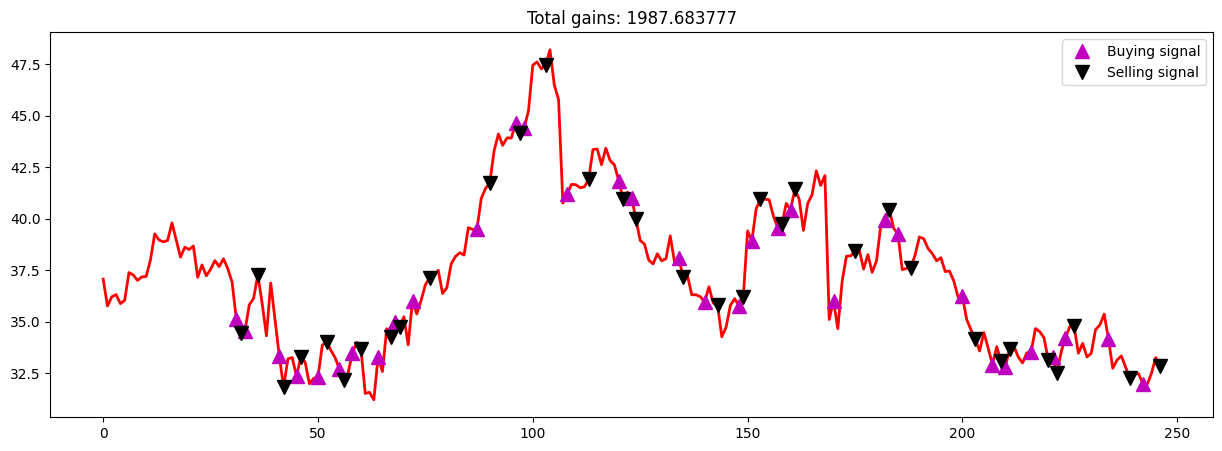


FINAL SUMMARY - ALL TICKERS

------------------------------------------------------------------------------------------
VALIDATION SET RESULTS
------------------------------------------------------------------------------------------
Ticker   DQN Return%  B&H Return%  Outperform%  Win Rate%  Trades  
------------------------------------------------------------------------------------------
CHWY     164.48       94.27        70.21        64.5       62      

------------------------------------------------------------------------------------------
TEST SET RESULTS
------------------------------------------------------------------------------------------
Ticker   DQN Return%  B&H Return%  Outperform%  Win Rate%  Trades  
------------------------------------------------------------------------------------------
CHWY     19.88        -13.81       33.68        57.6       66      

------------------------------------------------------------------------------------------
AVERAGE PERFORMANCE

In [11]:
# =============================================================================
# EVALUATE ALL TICKERS ON VALIDATION AND TEST SETS
# =============================================================================
validation_results = []
test_results = []

print("=" * 70)
print("EVALUATION PIPELINE - ALL TICKERS")
print("=" * 70)

for ticker in tickers:
    print(f"\n{'*'*70}")
    print(f"* EVALUATING: {ticker}")
    print(f"{'*'*70}")
    
    # Load data for this ticker
    train_set, val_set, test_set = load_ticker_data(ticker)
    
    # Get the trained agent for this ticker
    agent = trained_agents[ticker]
    
    # Recreate feature builder (needed for evaluation)
    feature_builder = OHLCVWithIndicators(window_size=window_size)
    
    # Evaluate on validation set
    val_result = evaluate_ticker(
        ticker=ticker,
        agent=agent,
        eval_set=val_set,
        feature_builder=feature_builder,
        window_size=window_size,
        initial_capital=initial_capital,
        transaction_cost=transaction_cost,
        eval_type="VALIDATION"
    )
    validation_results.append(val_result)
    
    # Evaluate on test set
    test_result = evaluate_ticker(
        ticker=ticker,
        agent=agent,
        eval_set=test_set,
        feature_builder=feature_builder,
        window_size=window_size,
        initial_capital=initial_capital,
        transaction_cost=transaction_cost,
        eval_type="TEST"
    )
    test_results.append(test_result)

# =============================================================================
# SUMMARY TABLE FOR ALL TICKERS
# =============================================================================
print("\n" + "=" * 90)
print("FINAL SUMMARY - ALL TICKERS")
print("=" * 90)

# Validation Summary
print("\n" + "-" * 90)
print("VALIDATION SET RESULTS")
print("-" * 90)
print(f"{'Ticker':<8} {'DQN Return%':<12} {'B&H Return%':<12} {'Outperform%':<12} {'Win Rate%':<10} {'Trades':<8}")
print("-" * 90)
for r in validation_results:
    outperf = r['dqn_return_pct'] - r['bh_return_pct']
    print(f"{r['ticker']:<8} {r['dqn_return_pct']:<12.2f} {r['bh_return_pct']:<12.2f} {outperf:<12.2f} {r['win_rate']:<10.1f} {r['total_trades']:<8}")

# Test Summary
print("\n" + "-" * 90)
print("TEST SET RESULTS")
print("-" * 90)
print(f"{'Ticker':<8} {'DQN Return%':<12} {'B&H Return%':<12} {'Outperform%':<12} {'Win Rate%':<10} {'Trades':<8}")
print("-" * 90)
for r in test_results:
    outperf = r['dqn_return_pct'] - r['bh_return_pct']
    print(f"{r['ticker']:<8} {r['dqn_return_pct']:<12.2f} {r['bh_return_pct']:<12.2f} {outperf:<12.2f} {r['win_rate']:<10.1f} {r['total_trades']:<8}")

# Average performance
print("\n" + "-" * 90)
print("AVERAGE PERFORMANCE")
print("-" * 90)
avg_val_dqn = sum(r['dqn_return_pct'] for r in validation_results) / len(validation_results)
avg_val_bh = sum(r['bh_return_pct'] for r in validation_results) / len(validation_results)
avg_test_dqn = sum(r['dqn_return_pct'] for r in test_results) / len(test_results)
avg_test_bh = sum(r['bh_return_pct'] for r in test_results) / len(test_results)

print(f"Validation - DQN Avg: {avg_val_dqn:.2f}%, B&H Avg: {avg_val_bh:.2f}%, Outperformance: {avg_val_dqn - avg_val_bh:.2f}%")
print(f"Test       - DQN Avg: {avg_test_dqn:.2f}%, B&H Avg: {avg_test_bh:.2f}%, Outperformance: {avg_test_dqn - avg_test_bh:.2f}%")

print("\n" + "=" * 90)
print("EVALUATION COMPLETE")
print("=" * 90)


Loading model from: models/CHWY_final.keras
TEST SET EVALUATION: CHWY

Starting Capital: $10000.00
TEST Period: 226 trading days
----------------------------------------------------------------------
Action   Time     Price        Shares       Trade P/L    TxnCost    Portfolio   
----------------------------------------------------------------------
BUY      31       $35.12       284.4533     -$10.00      $10.00     $9990.00    
SELL     32       $34.46       284.4533     -$207.54     $9.80      $9792.46    
BUY      33       $34.55       283.1452     -$9.79       $9.79      $9782.67    
SELL     36       $37.26       283.1452     $746.98      $10.55     $10539.44   
BUY      41       $33.32       315.9934     -$10.54      $10.54     $10528.90   
SELL     42       $31.83       315.9934     -$491.43     $10.06     $10048.01   
BUY      45       $32.35       310.2926     -$10.05      $10.05     $10037.96   
SELL     46       $33.29       310.2926     $271.30      $10.33     $10319.31   

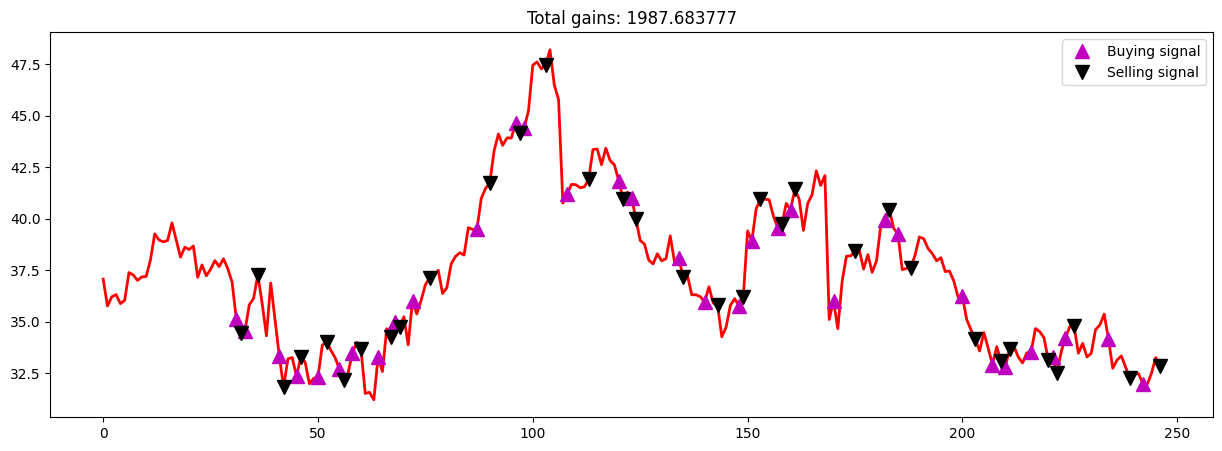

In [12]:
# =============================================================================
# UTILITY: LOAD AND EVALUATE A SAVED MODEL
# =============================================================================
def load_and_evaluate_ticker(ticker, model_path=None, eval_type="both"):
    """
    Load a saved model and evaluate it on validation and/or test data.
    
    Args:
        ticker: Stock ticker symbol (e.g., 'AAPL')
        model_path: Path to saved model. If None, uses 'models/{ticker}_final.keras'
        eval_type: "validation", "test", or "both"
        
    Returns:
        results: Dictionary with evaluation results
    """
    if model_path is None:
        model_path = f"models/{ticker}_final.keras"
    
    print(f"\nLoading model from: {model_path}")
    
    # Create agent in evaluation mode with the saved model
    feature_builder = OHLCVWithIndicators(window_size=window_size)
    state_size = feature_builder.obs_dim
    agent = Agent(state_size, initial_capital=initial_capital, is_eval=True, model_name=model_path)
    
    # Load ticker data
    train_set, val_set, test_set = load_ticker_data(ticker)
    
    results = {}
    
    if eval_type in ["validation", "both"]:
        val_result = evaluate_ticker(
            ticker=ticker,
            agent=agent,
            eval_set=val_set,
            feature_builder=feature_builder,
            window_size=window_size,
            initial_capital=initial_capital,
            transaction_cost=transaction_cost,
            eval_type="VALIDATION"
        )
        results['validation'] = val_result
    
    if eval_type in ["test", "both"]:
        # Need to recreate agent/feature builder since evaluate_ticker modifies them
        feature_builder = OHLCVWithIndicators(window_size=window_size)
        agent = Agent(state_size, initial_capital=initial_capital, is_eval=True, model_name=model_path)
        
        test_result = evaluate_ticker(
            ticker=ticker,
            agent=agent,
            eval_set=test_set,
            feature_builder=feature_builder,
            window_size=window_size,
            initial_capital=initial_capital,
            transaction_cost=transaction_cost,
            eval_type="TEST"
        )
        results['test'] = test_result
    
    return results


# Example usage (uncomment to run):
results = load_and_evaluate_ticker('CHWY', eval_type='test')
# results = load_and_evaluate_ticker('AAPL', eval_type='test')
# results = load_and_evaluate_ticker('MSFT', eval_type='test')




# print("\n" + "=" * 70)
# print("UTILITY FUNCTION LOADED: load_and_evaluate_ticker()")
# print("=" * 70)
# print("""
# Usage examples:
#   # Evaluate AAPL with final model on both val and test
#   results = load_and_evaluate_ticker('AAPL')
  
#   # Evaluate MSFT with a specific pass model on test only
#   results = load_and_evaluate_ticker('MSFT', model_path='models/MSFT_pass1.keras', eval_type='test')
  
#   # Evaluate GOOGL on validation only
#   results = load_and_evaluate_ticker('GOOGL', eval_type='validation')
# """)